# Notebook 3: Plots
## Plots de QBER, % P_sift y SKR por escenario industrial

**Entrada:** CSV de métricas generados por el Notebook 2.  
**Salida:** Gráficas con media ± desviación estadística entre semillas.

Modos de uso disponibles:
- **Un escenario:** comparativa de las 3 métricas en un panel.
- **Todos los escenarios:** comparativa multi-escenario para cada métrica.


## 0. Imports y estilo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, glob, json
from pathlib import Path

# ── Estilo blanco y negro para publicación ──────────────────────────────
plt.rcParams.update({
    "figure.facecolor"  : "#ffffff",  # Fondo de la imagen (detrás de todo)
    "axes.facecolor"    : "#ffffff",  # Fondo de los ejes (detrás de títulos y etiquetas)
    "axes.edgecolor"    : "#000000",  # Borde de los ejes
    "axes.labelcolor"   : "#000000",  # Texto de los ejes
    "axes.titlecolor"   : "#000000",  # Título del gráfico
    "axes.titlesize"    : 18,
    "axes.grid"         : True,
    "grid.color"        : "#cccccc",  # Cuadrícula gris claro
    "grid.linestyle"    : "--",
    "grid.linewidth"    : 0.6,
    "xtick.color"       : "#000000",  # Ticks eje X
    "ytick.color"       : "#000000",  # Ticks eje Y
    "text.color"        : "#000000",  # Texto general
    "legend.facecolor"  : "#ffffff",  # Fondo de la leyenda
    "legend.edgecolor"  : "#000000",  # Borde de la leyenda
    "legend.labelcolor" : "#000000",  # Texto de la leyenda
    "font.family"       : "serif",
    "font.serif"        : ["STIXTwo Text", "Times New Roman", "Times", "Palatino", "DejaVu Serif"],
    "mathtext.fontset"  : "stix",
    "font.size"         : 12,
    "axes.labelsize"    : 16,
    "xtick.labelsize"   : 14,
    "ytick.labelsize"   : 14,
    "lines.linewidth"   : 2.0,
    "figure.dpi"        : 130,
})

# Paleta de colores para múltiples escenarios
PALETTE = [
    "#58a6ff", "#f78166", "#3fb950", "#d2a8ff", "#ffa657",
    "#79c0ff", "#ff7b72", "#56d364", "#bc8cff", "#ffb757",
    "#a5d6ff", "#ffa198",
]
WARN_COLOR  = "#f78166"
SHADE_ALPHA = 0.20


## 1. Carga de datos

In [2]:
METRICS_DIR  = "output_metrics"
PLOTS_DIR    = "output_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

def load_metrics(metrics_dir: str) -> dict:
    """Carga todos los CSV de métricas. Retorna dict {nombre: DataFrame}."""
    files = sorted(glob.glob(os.path.join(metrics_dir, "metrics_scenario_*.csv")))
    if not files:
        raise FileNotFoundError(f"No hay archivos de métricas en '{metrics_dir}'. "
                                "Ejecuta primero el Notebook 2.")
    data = {}
    for f in files:
        key = Path(f).stem.replace("metrics_scenario_", "sc")
        data[key] = pd.read_csv(f)
    print(f"Cargados {len(data)} escenarios.")
    return data

scenarios_data = load_metrics(METRICS_DIR)

# Leer nombres desde los JSON (para etiquetas en gráficas)
JSON_DIR = "."
sc_names = {}
for jf in sorted(glob.glob(os.path.join(JSON_DIR, "scenario_*.json"))):
    with open(jf) as f:
        sc = json.load(f)
    key = f"sc{sc['id']:02d}"
    sc_names[key] = f"{sc['id']:02d}. {sc['name']}"

# Columnas de semillas individuales
def seed_cols(df, metric):
    return [c for c in df.columns if c.startswith(f"{metric}_seed_")]


Cargados 12 escenarios.


## 2. Función base de plot

In [3]:
def plot_metric(ax, df: pd.DataFrame, metric: str, label: str,
                color: str, shade_color: str,
                pct_fmt=False, log_y=False, threshold=None,
                show_seeds=True):
    """
    Dibuja una métrica (QBER, absorción o SKR) en un eje.
    Muestra trazas por semilla, banda ±1σ y línea de media.
    """
    dist = df["distancia"].values
    mean = df[f"{metric}_mean"].values * 100  # Convertir a porcentaje
    std  = df[f"{metric}_std"].values * 100  # Convertir a porcentaje

    # Trazas por semilla
    if show_seeds:
        for sc in seed_cols(df, metric):
            ax.plot(dist, df[sc].values * 100, color=shade_color,
                    alpha=0.30, linewidth=0.9, linestyle="--")

    # Banda ±1σ
    lo = mean - std
    if log_y:
        lo = np.maximum(lo, 1e-12)
    ax.fill_between(dist, lo, mean + std,
                    color=shade_color, alpha=SHADE_ALPHA)

    # Media
    ax.plot(dist, mean, color=color, linewidth=2.0,
            label=label, zorder=5)

    # No mostrar threshold/límite teórico

    # Etiquetas de ejes
    if metric == "absorption":
        ax.set_ylabel("Sifted Key (%)")
    elif metric == "skr":
        ax.set_ylabel("SKR (%)")
    elif metric == "qber":
        ax.set_ylabel("QBER (%)")
    ax.set_xlabel("Distance (km)")

    if pct_fmt:
        # Formateador personalizado para mostrar valores ya multiplicados por 100
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.1f}%'))

    if log_y:
        pos = mean[mean > 0]
        if len(pos) > 1 and pos.max() / pos.min() > 20:
            ax.set_yscale("log")

## 3. Plot individual: panel 3×1 para un escenario

In [4]:
def plot_scenario(sc_key: str, save=True):
    """Genera el panel (QBER | Absorción | SKR) para un escenario."""
    df    = scenarios_data[sc_key]
    name  = sc_names.get(sc_key, sc_key)
    color = PALETTE[0]
    shade = PALETTE[1]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    # Quitar fondo oscuro manual
    # fig.patch.set_facecolor("#0d1117")
    fig.suptitle(f"{name}", color="#000000", fontsize=13, y=1.01)

    # ── QBER ──────────────────────────────────────────────────────────────
    plot_metric(axes[0], df, "qber", "QBER", color, shade,
                pct_fmt=True, threshold=0.11)
    axes[0].set_ylabel("QBER (%)")
    axes[0].set_title("QBER vs Distance", pad=8, color="#000000")
    axes[0].text(0.02, 0.97, "a)", transform=axes[0].transAxes,
                 fontsize=12, fontweight="bold", va="top", color="#000000")

    # ── Absorción ─────────────────────────────────────────────────────────
    plot_metric(axes[1], df, "absorption", "Absorción", color, shade,
                pct_fmt=True)
    axes[1].set_ylabel("Sifted Bit Probability (%)")
    axes[1].set_title("Sifted Bit Probability vs Distance", pad=8, color="#000000")
    axes[1].text(0.02, 0.97, "b)", transform=axes[1].transAxes,
                 fontsize=12, fontweight="bold", va="top", color="#000000")

    # ── SKR ───────────────────────────────────────────────────────────────
    plot_metric(axes[2], df, "skr", "SKR", color, shade, log_y=True)
    axes[2].set_ylabel("SKR (%)")
    axes[2].set_title("SKR vs Distance", pad=8, color="#000000")
    axes[2].text(0.02, 0.97, "c)", transform=axes[2].transAxes,
                 fontsize=12, fontweight="bold", va="top", color="#000000")

    plt.tight_layout()
    if save:
        path = os.path.join(PLOTS_DIR, f"panel_{sc_key}.png")
        plt.savefig(path, bbox_inches="tight", dpi=150, facecolor=fig.get_facecolor())
        print(f"  Guardado: {path}")
    plt.show()


## 4. Plots individuales de todos los escenarios

  Guardado: output_plots\panel_sc01_ideal.png


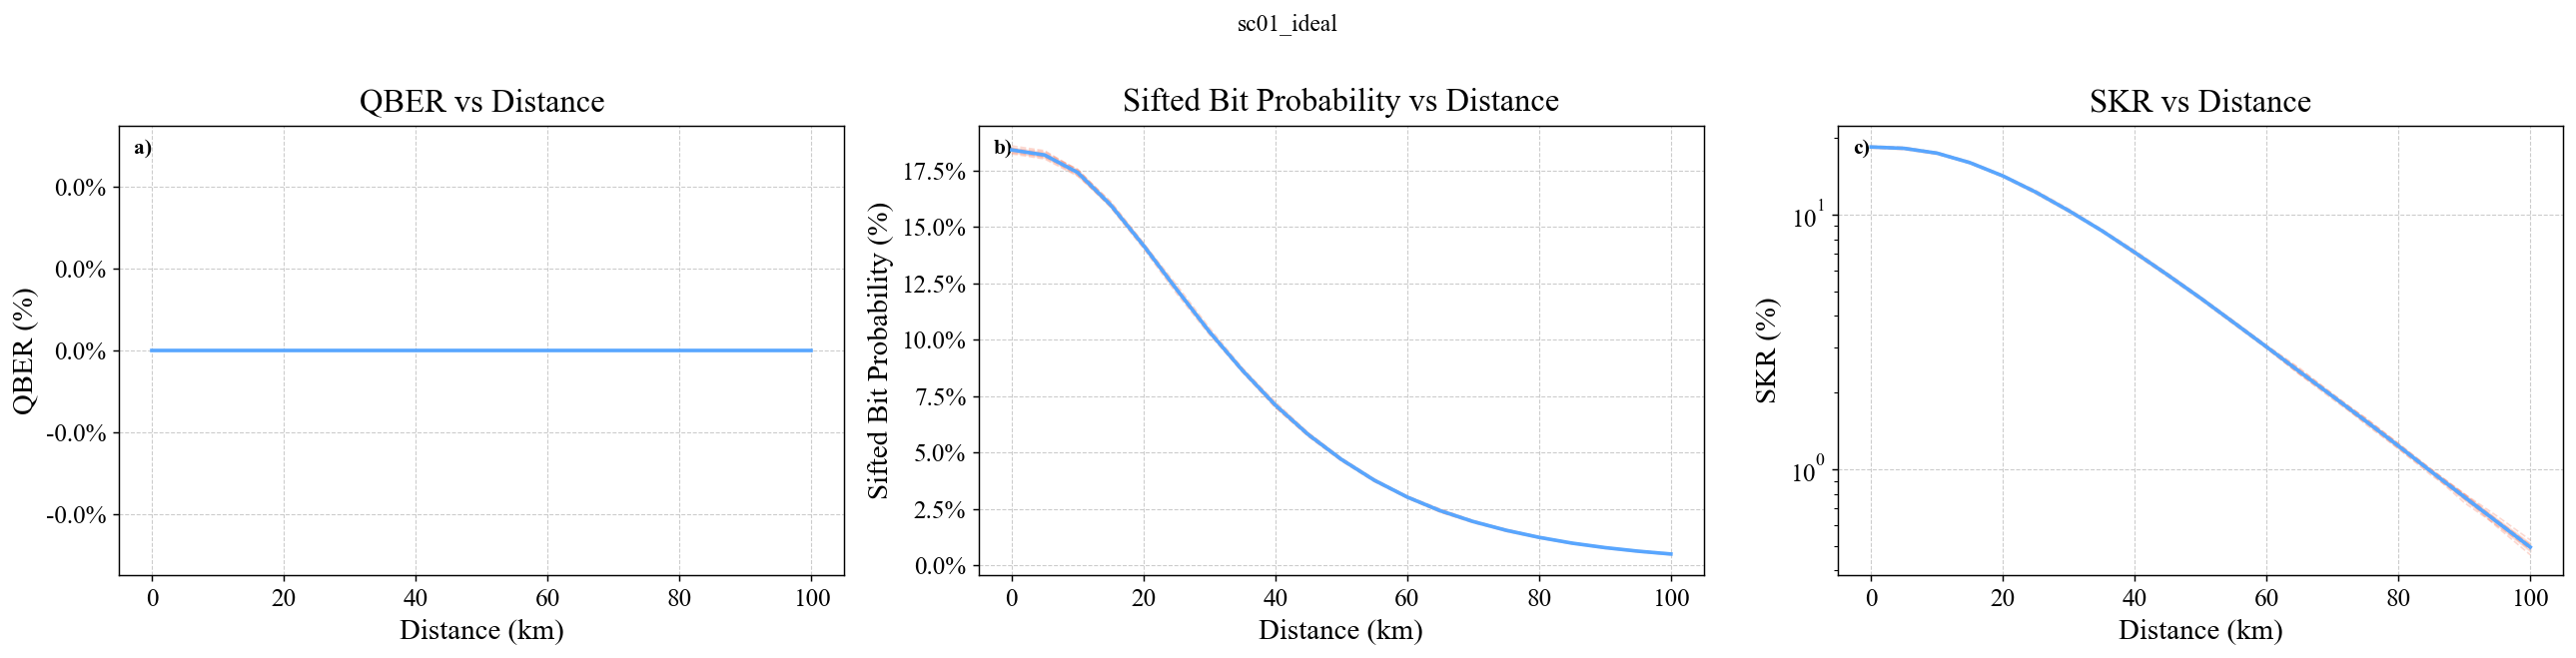

  Guardado: output_plots\panel_sc02_canal_con_ruido.png


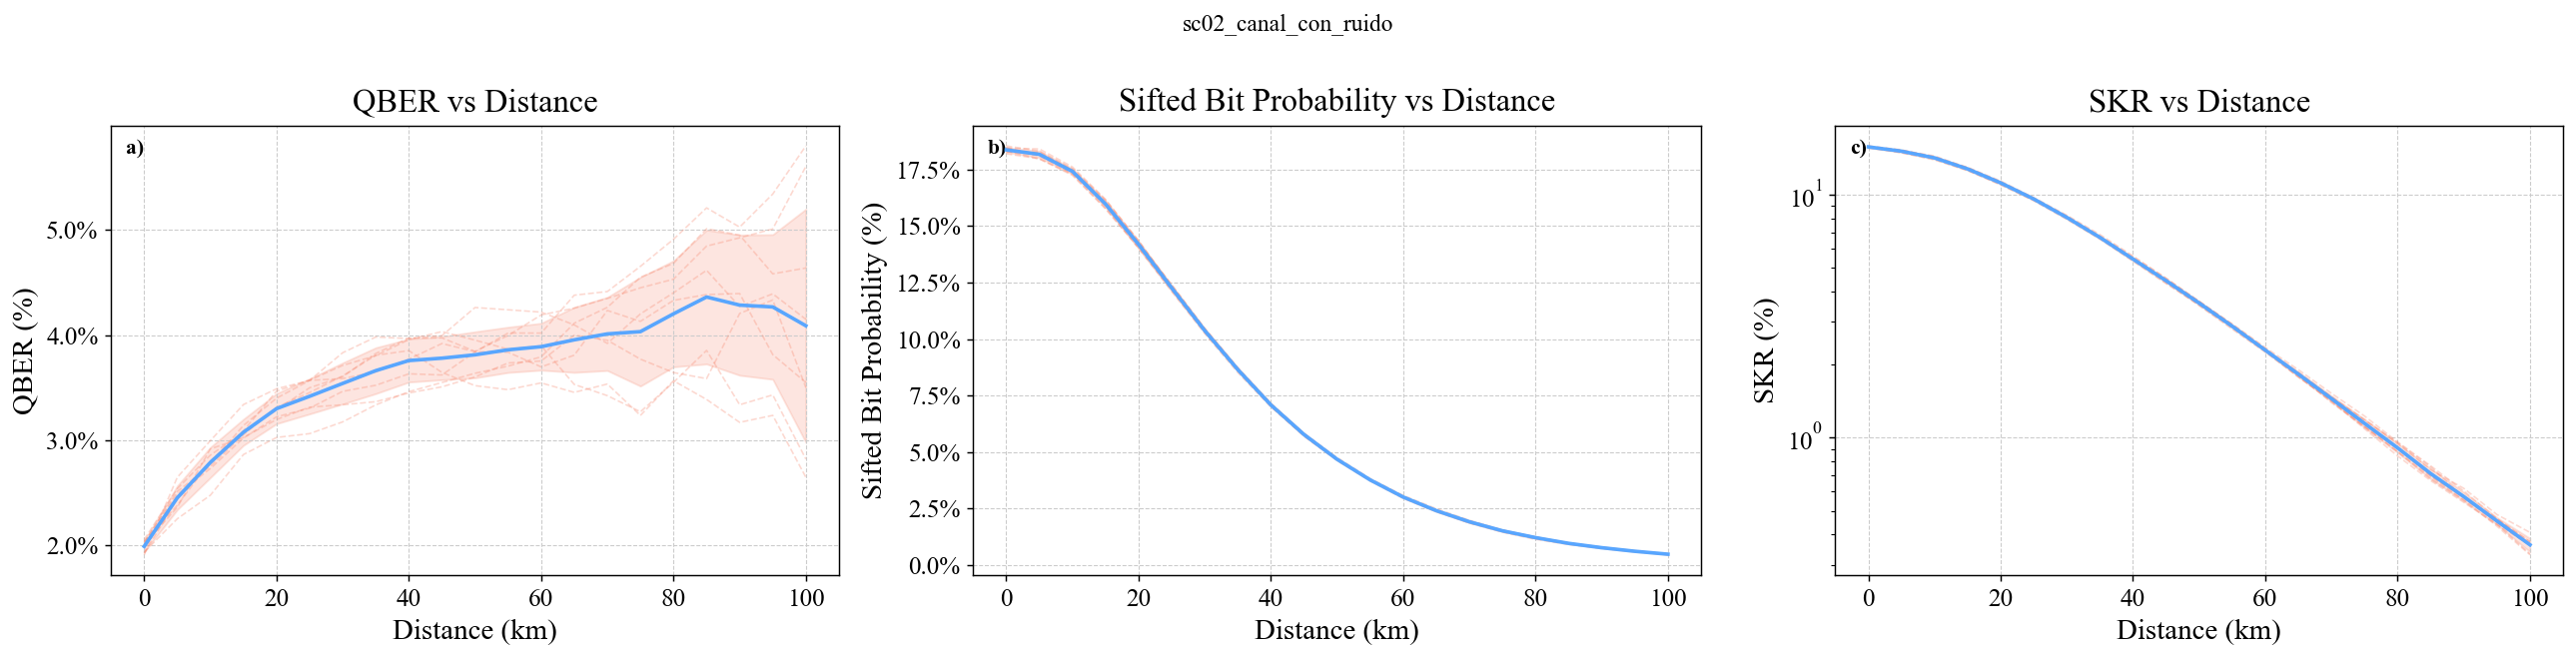

  Guardado: output_plots\panel_sc03_canal_con_ruido_alto.png


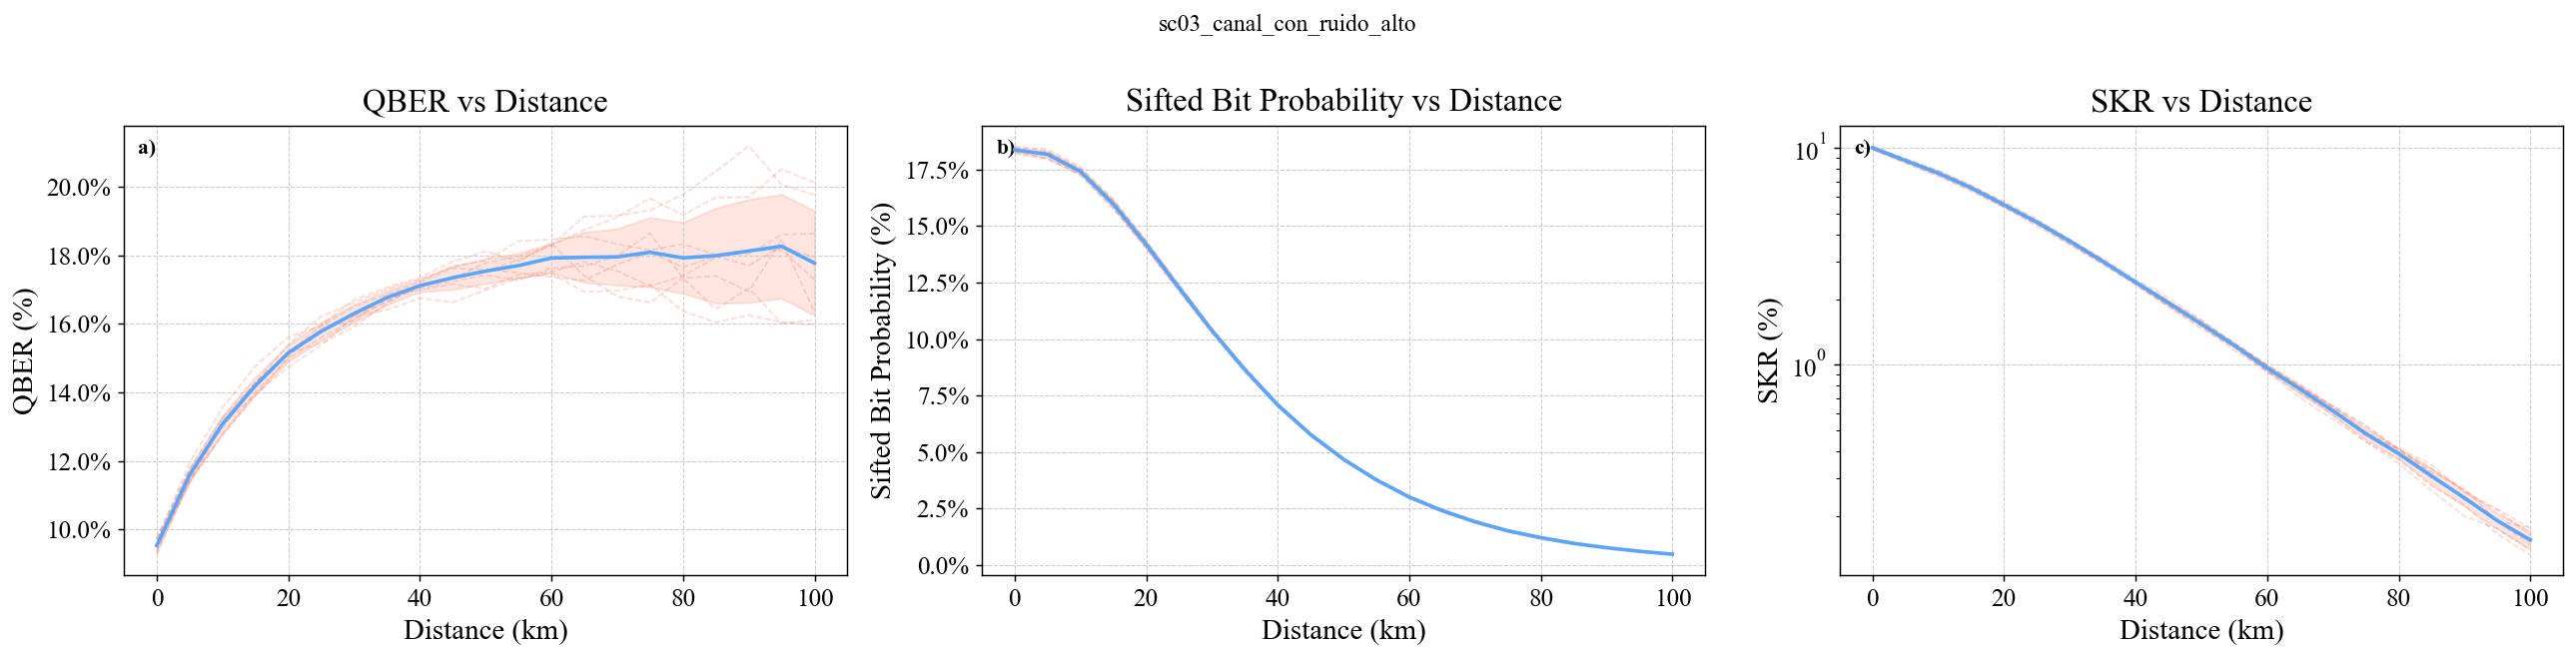

  Guardado: output_plots\panel_sc04_ataque_eve_parcial.png


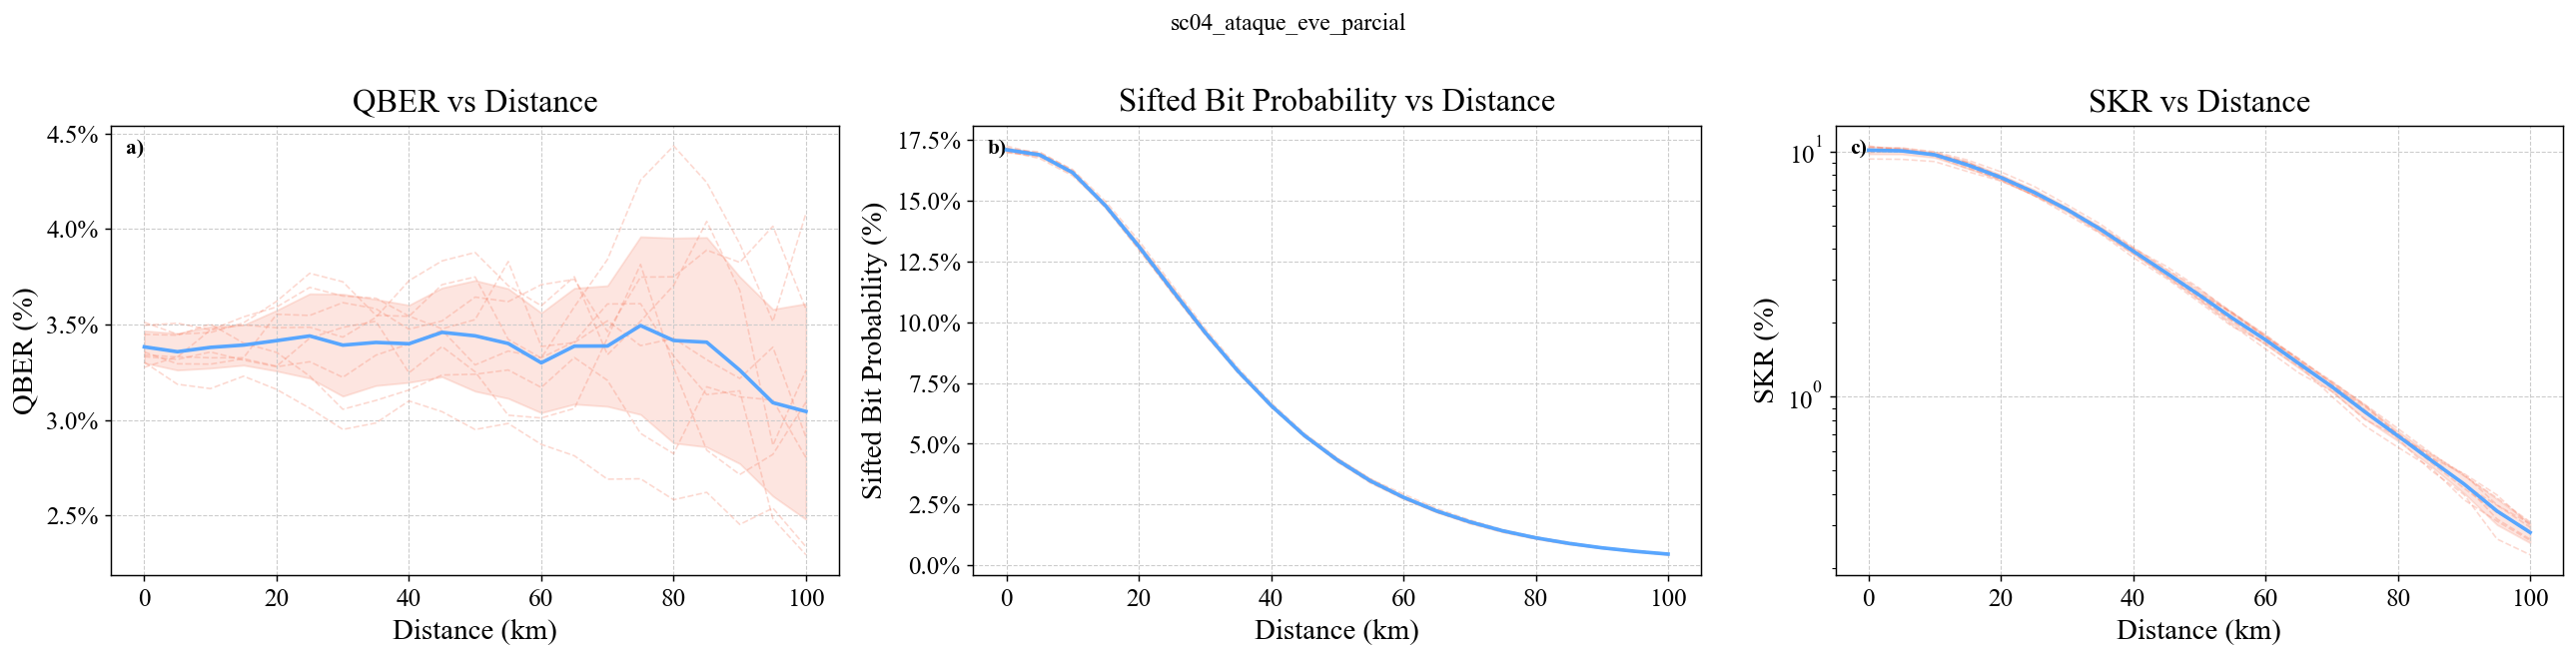

  Guardado: output_plots\panel_sc05_ataque_eve_total.png


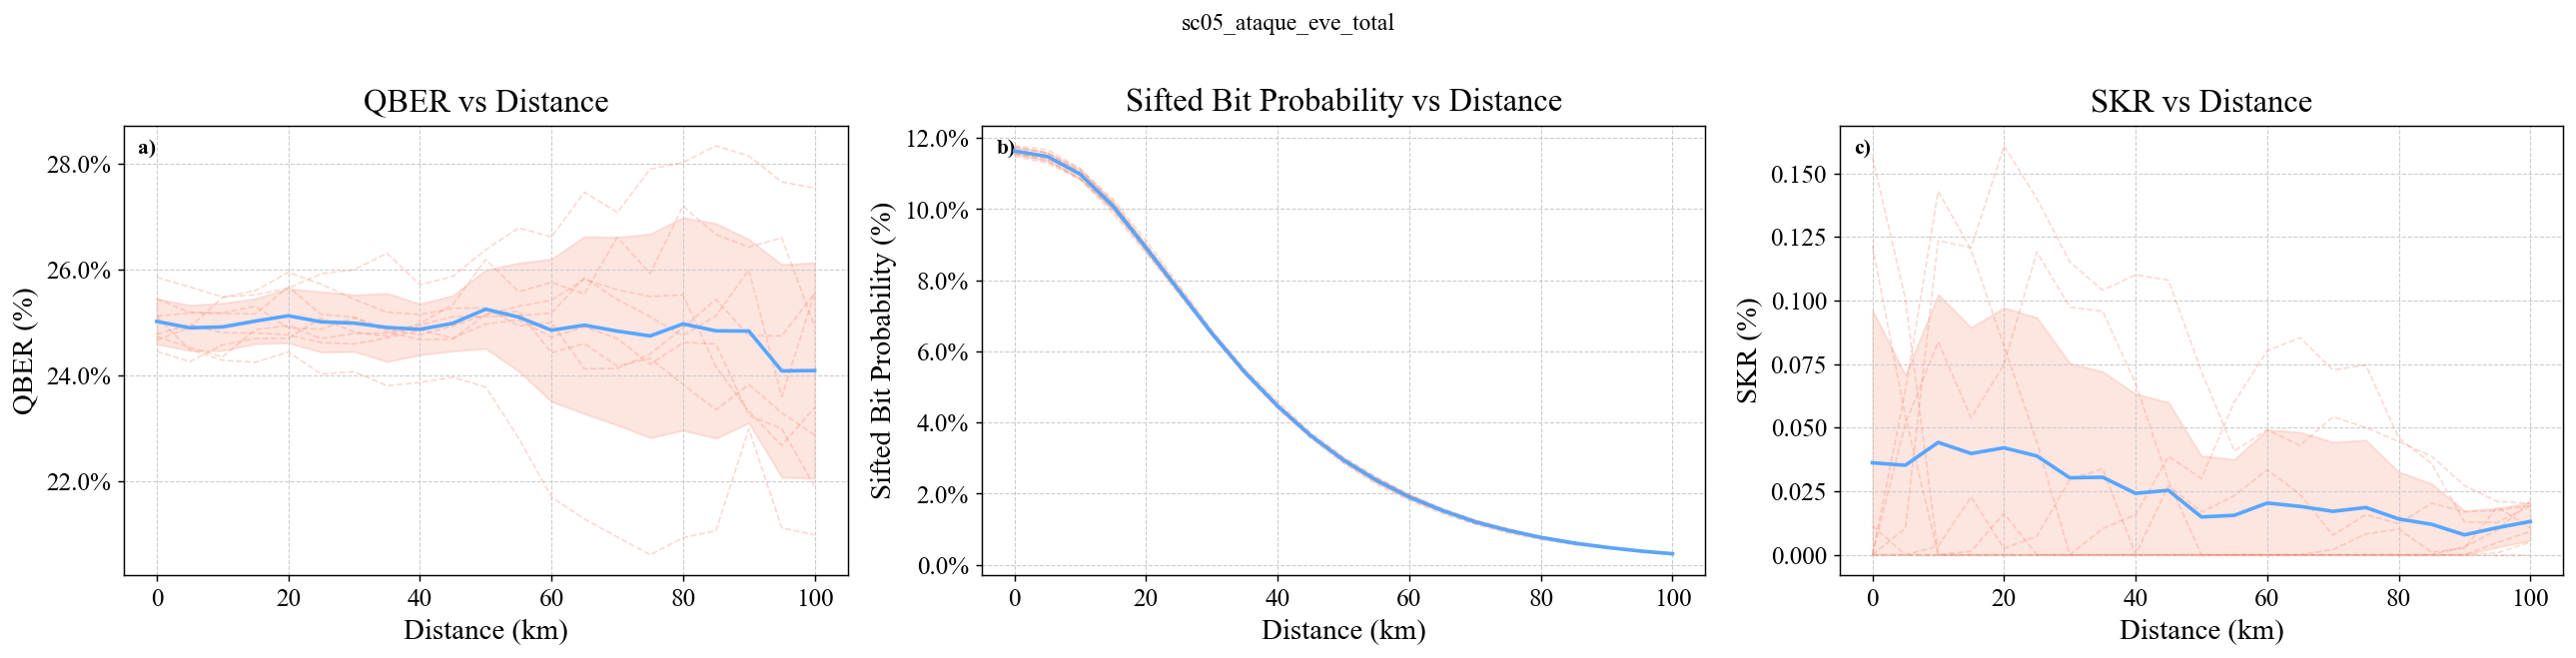

  Guardado: output_plots\panel_sc06_fibra_deteriorada.png


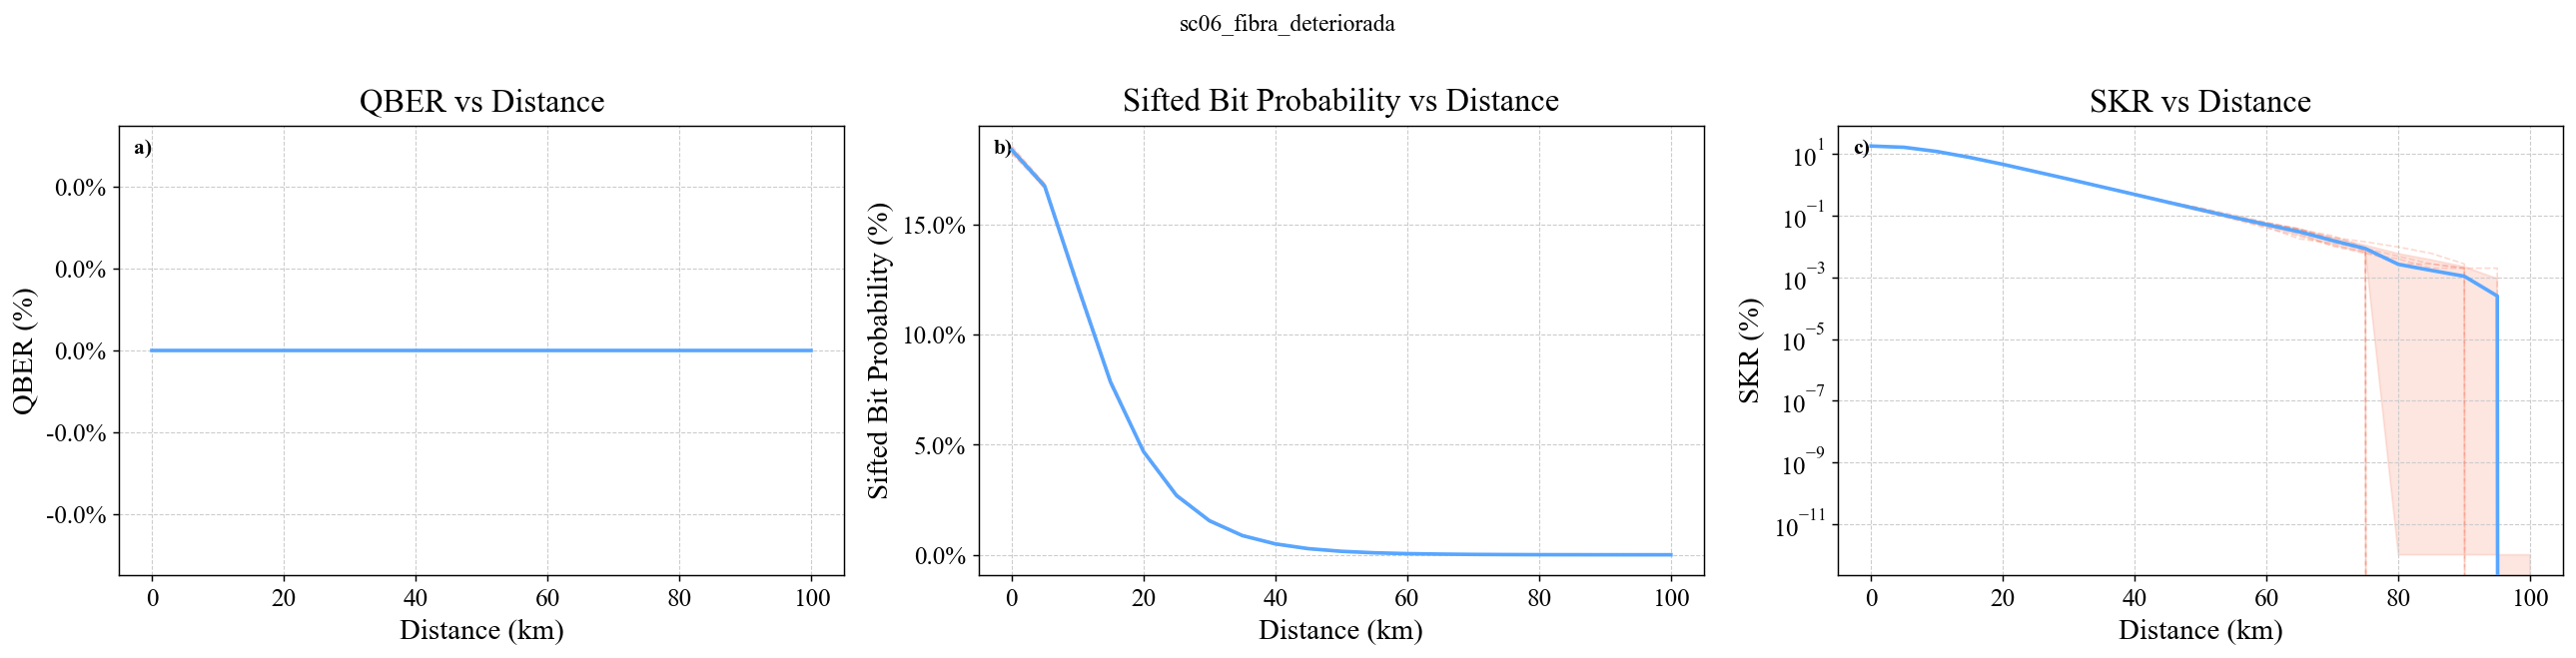

  Guardado: output_plots\panel_sc07_detector_ruidoso.png


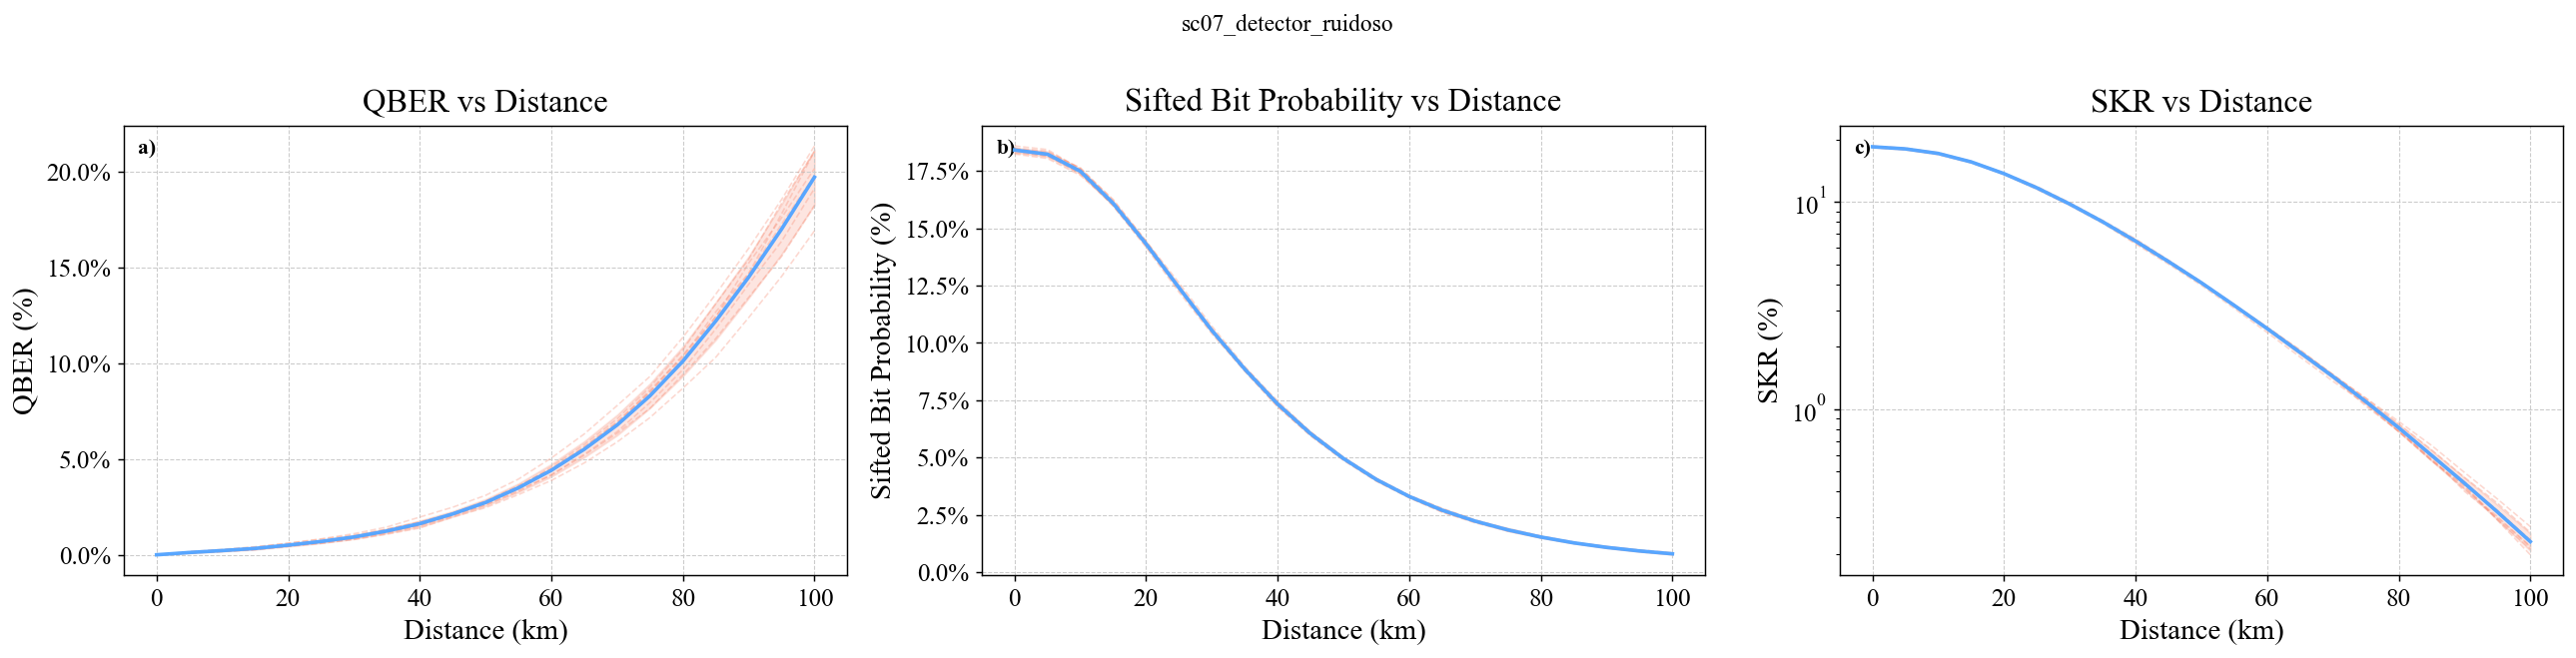

  Guardado: output_plots\panel_sc08_baja_eficiencia_detector.png


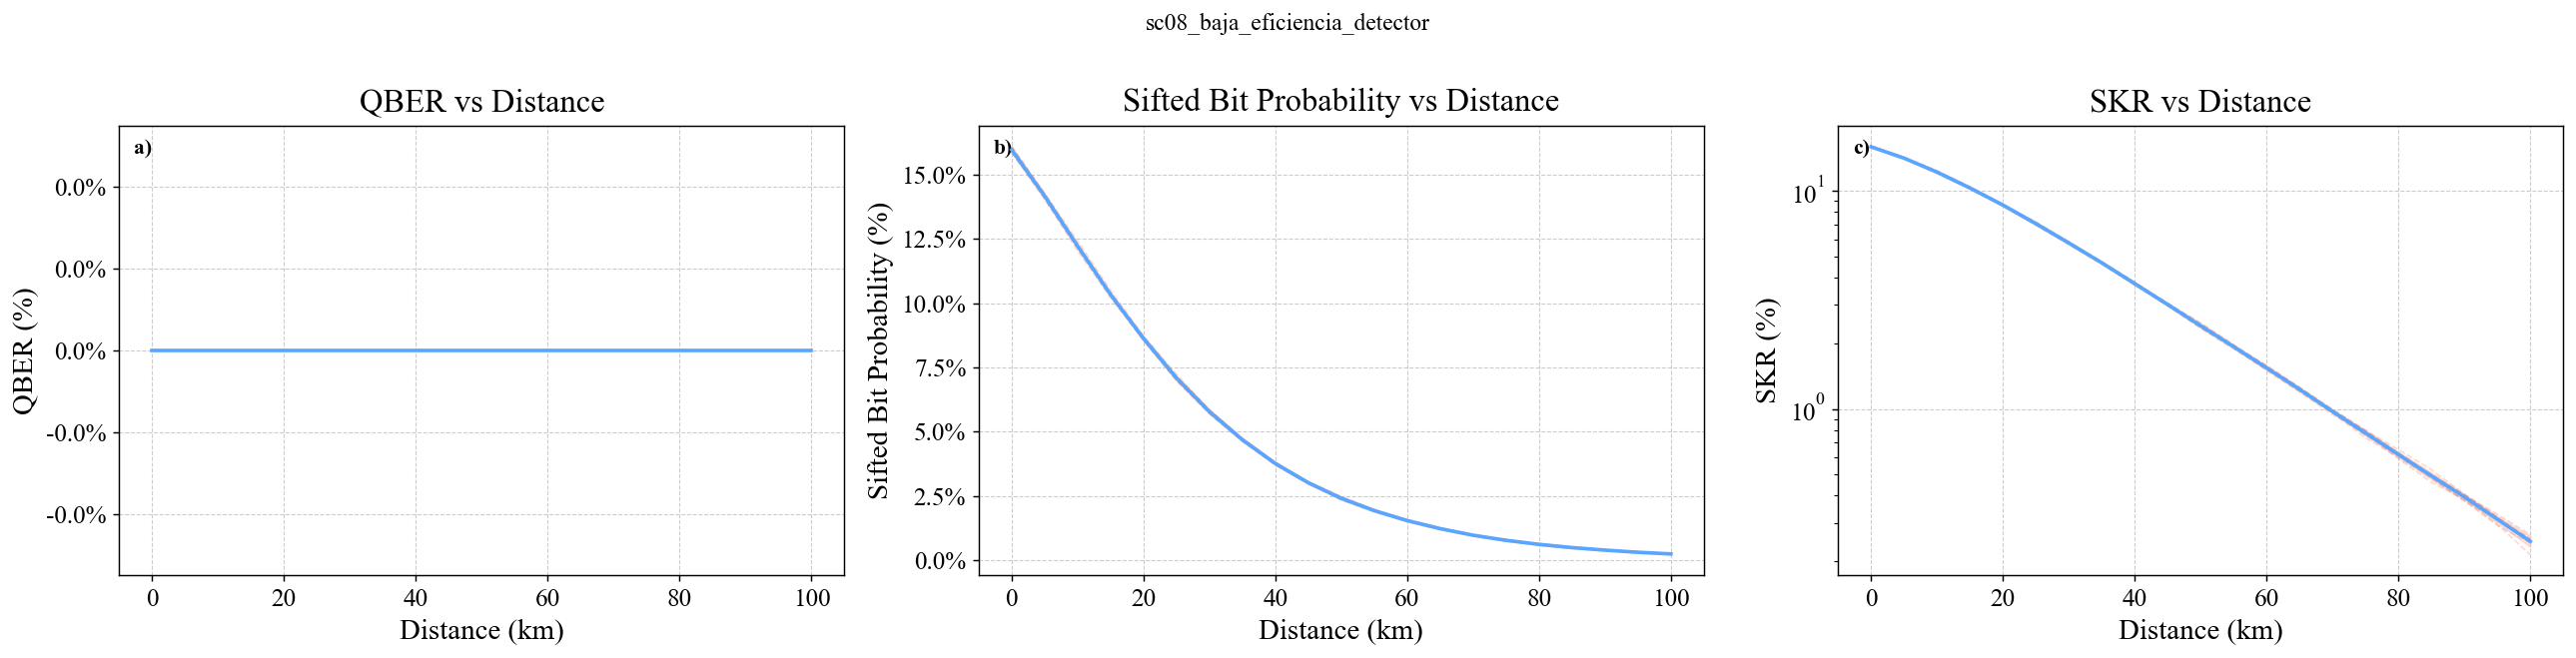

  Guardado: output_plots\panel_sc09_baja_intensidad_fuente.png


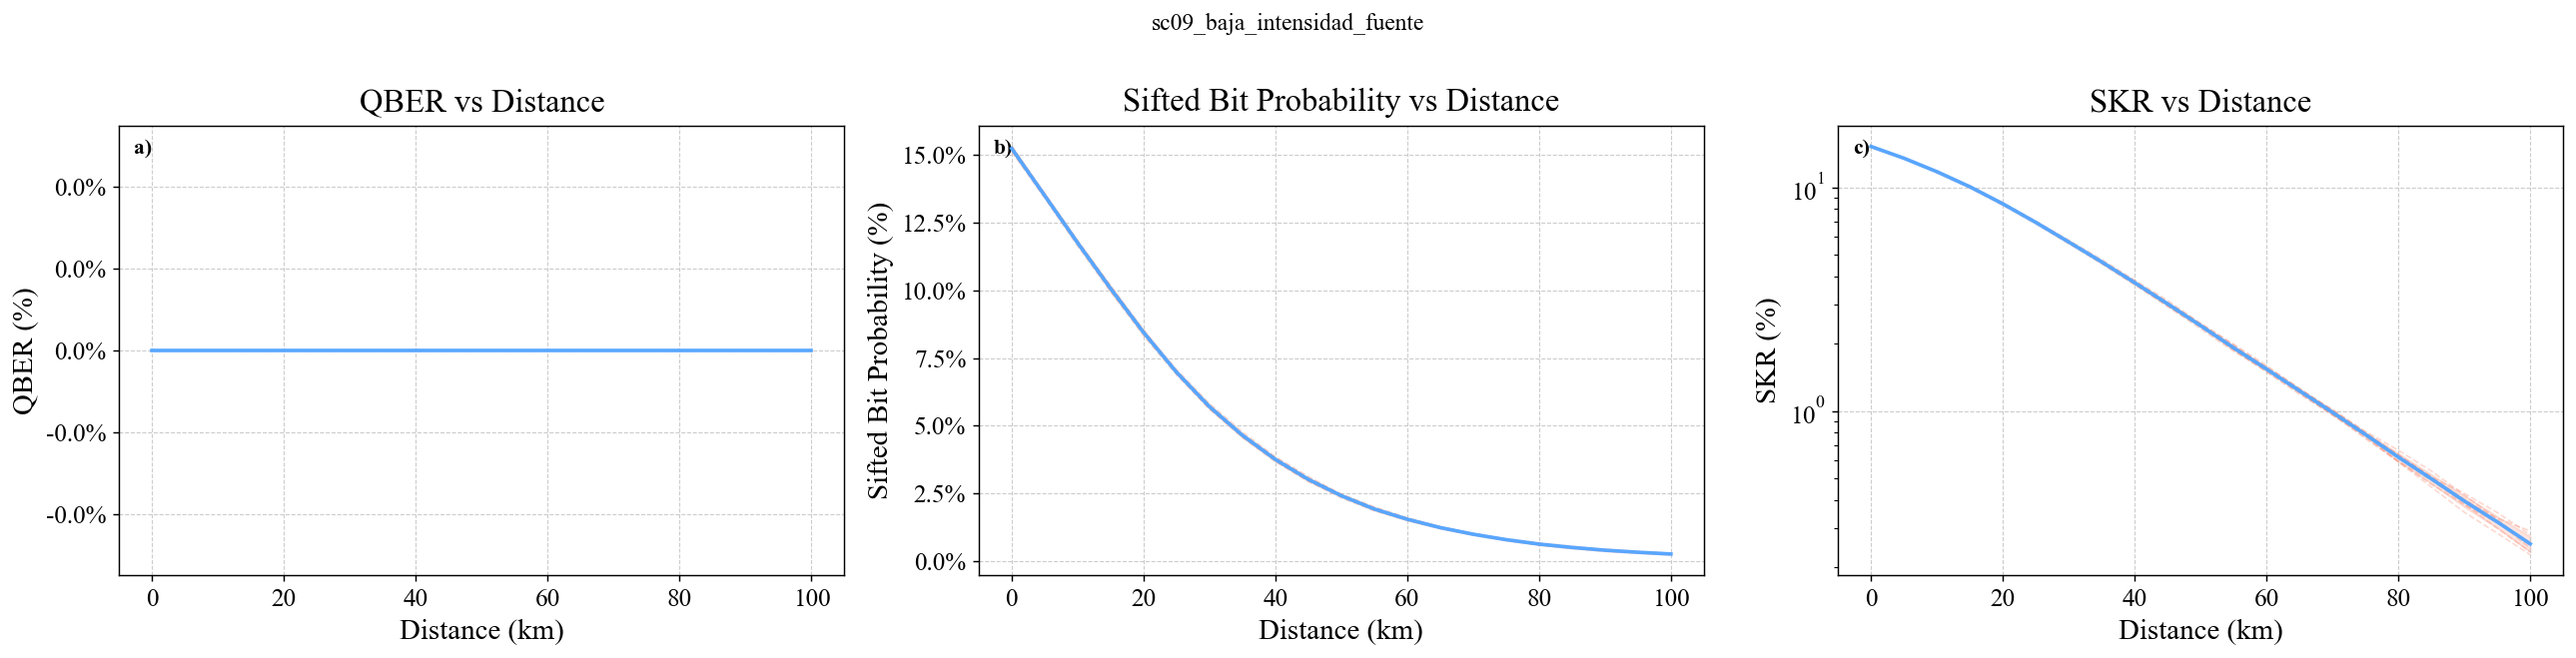

  Guardado: output_plots\panel_sc10_escenario_adverso_1.png


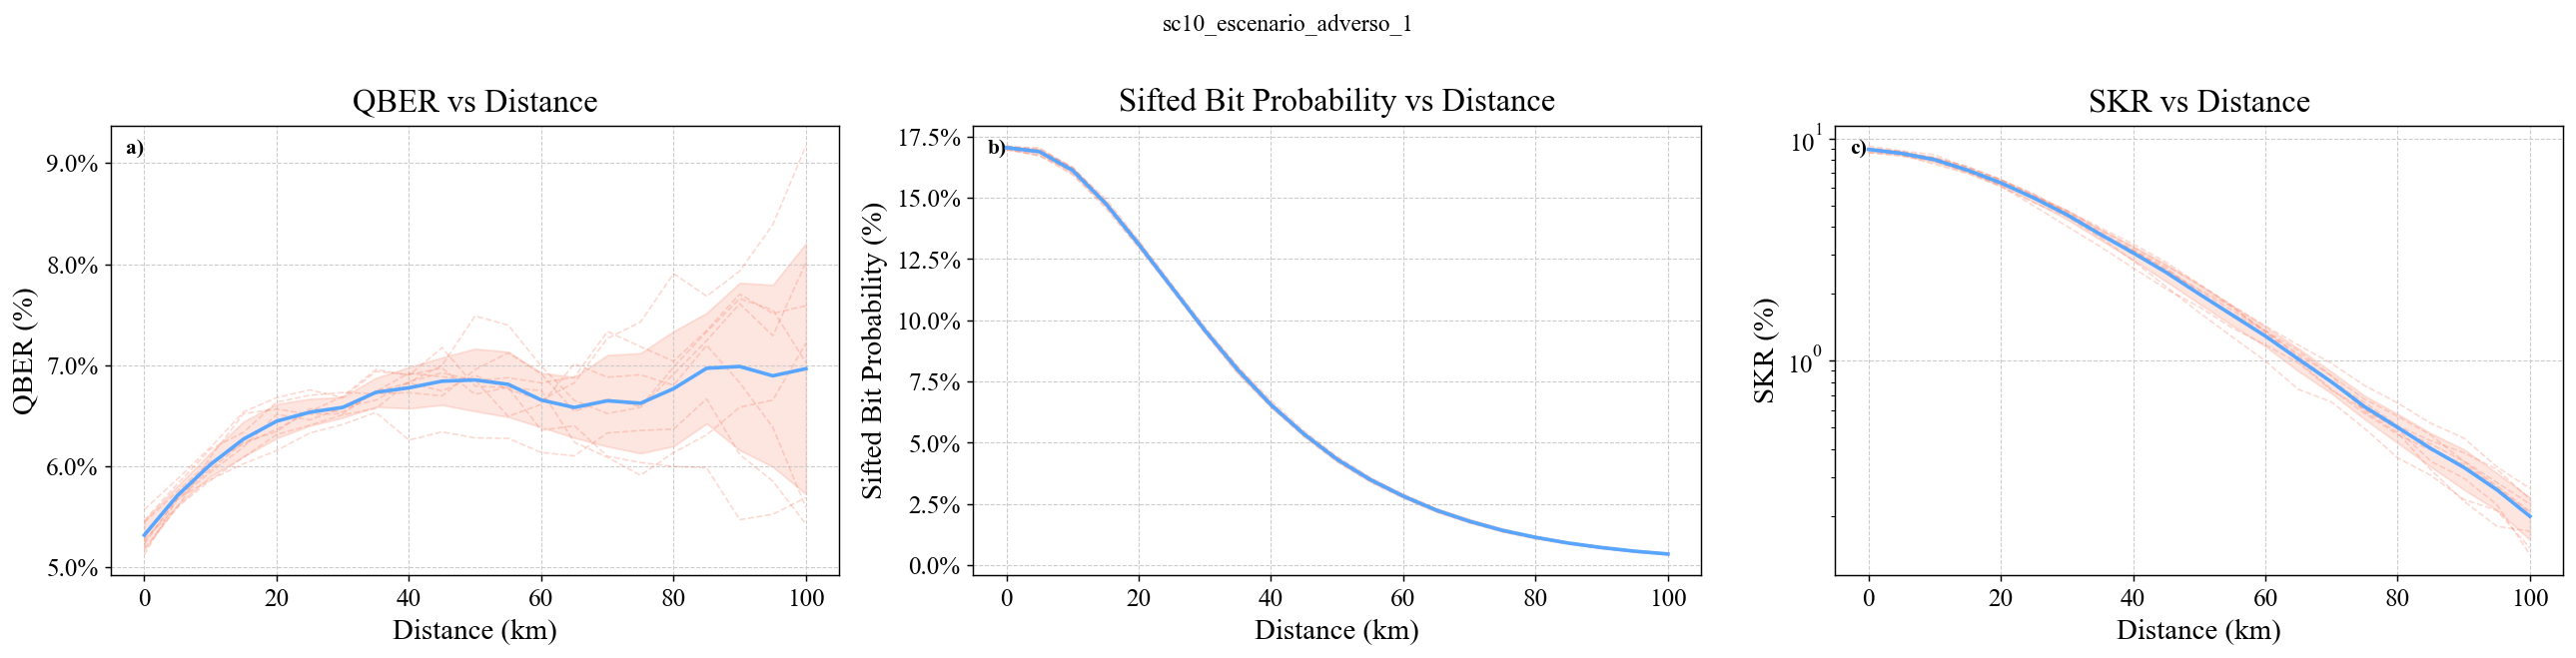

  Guardado: output_plots\panel_sc11_escenario_adverso_2.png


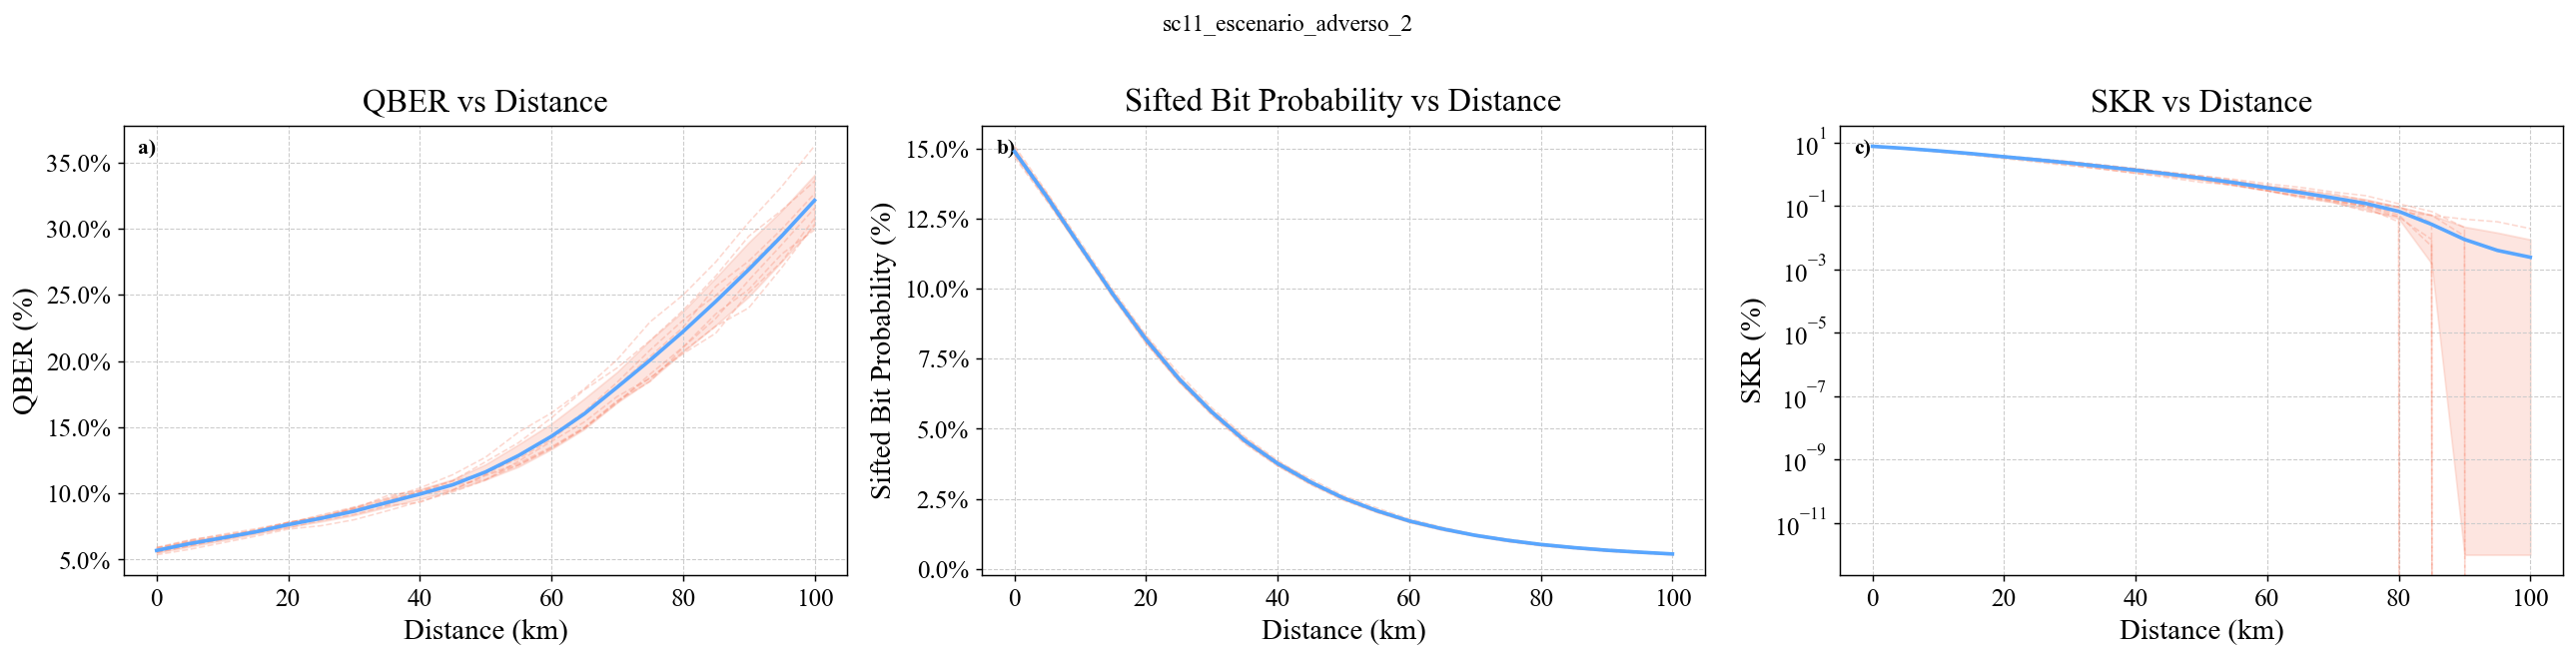

  Guardado: output_plots\panel_sc12_escenario_adverso_3.png


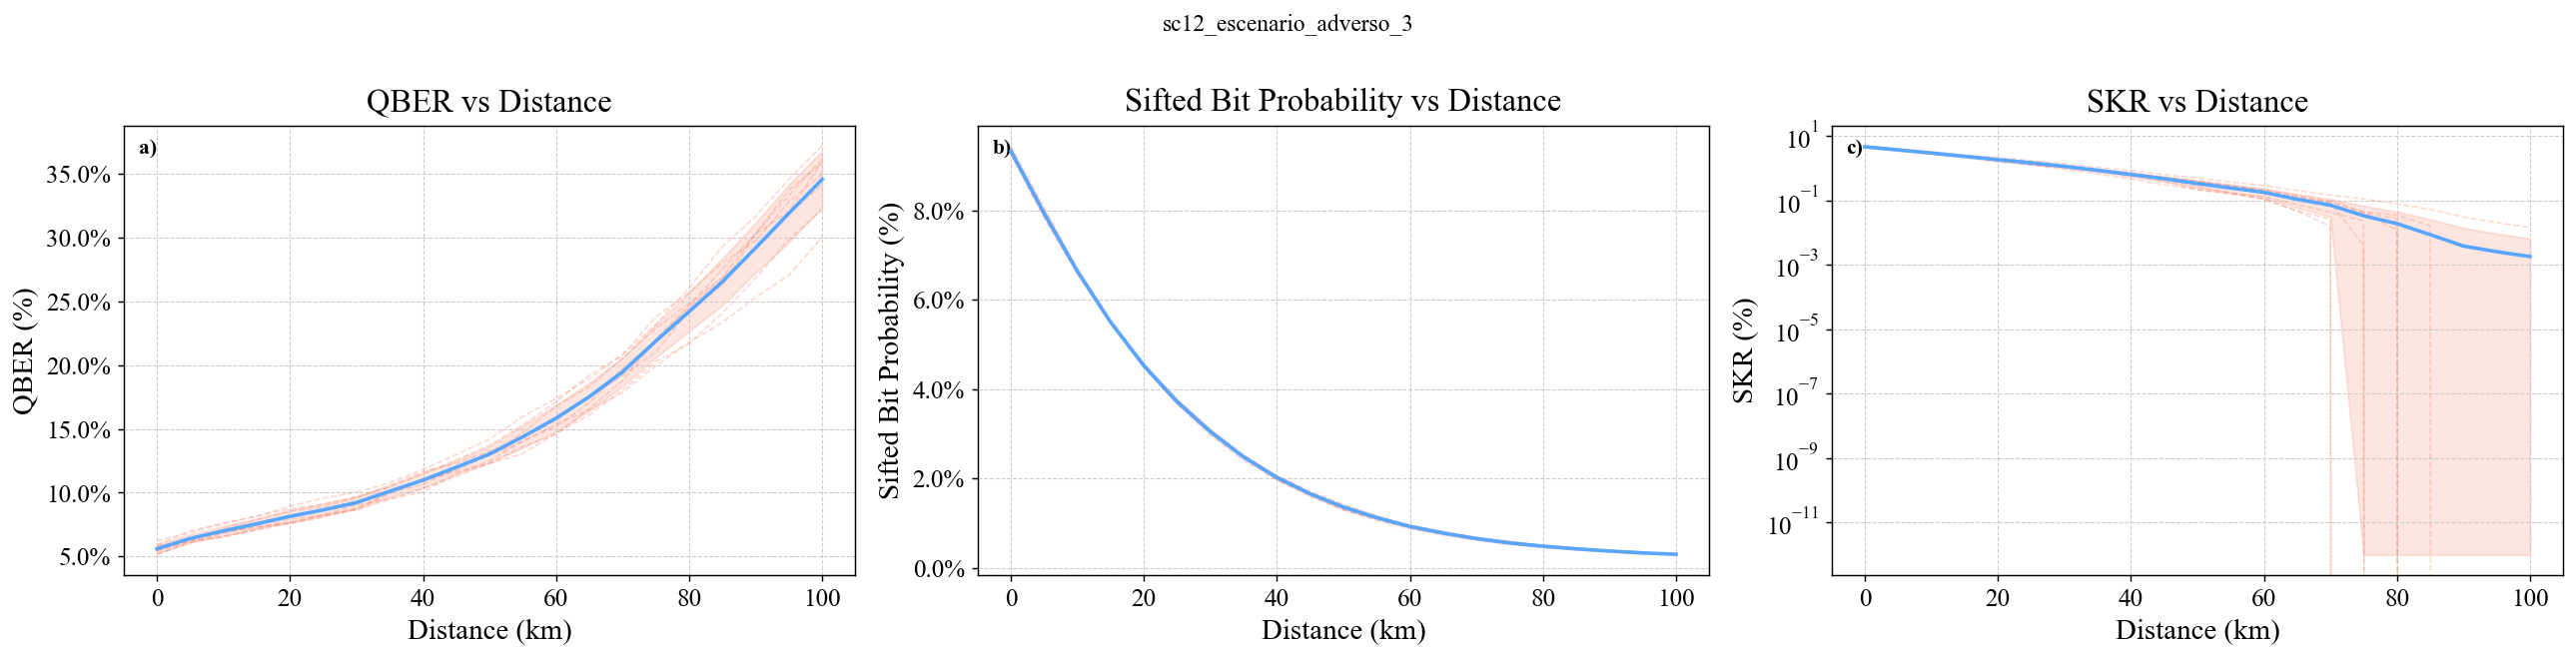

In [5]:
for key in sorted(scenarios_data.keys()):
    plot_scenario(key, save=True)


## 5. Comparativa multi-escenario — QBER

In [6]:
def plot_all_scenarios_metric(metric: str, ylabel: str, title: str,
                              pct_fmt=False, log_y=False,
                              threshold=None, fname=None):
    """
    Representa la métrica indicada para todos los escenarios en un solo plot.
    Cada escenario es una línea con su banda ±1σ.
    """
    keys = sorted(scenarios_data.keys())
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor("#ffffff")

    for i, key in enumerate(keys):
        df    = scenarios_data[key]
        color = PALETTE[i % len(PALETTE)]
        label = str(i+1)  # Números del 1 al 12 en la leyenda
        plot_metric(ax, df, metric, label, color, color,
                    pct_fmt=True, log_y=log_y,
                    threshold=None, show_seeds=False)

    # No mostrar threshold/límite teórico

    if pct_fmt:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=2))

    if log_y:
        all_means = np.concatenate([
            scenarios_data[k][f"{metric}_mean"].values * 100 for k in keys])
        pos = all_means[all_means > 0]
        if len(pos) > 1 and pos.max() / pos.min() > 20:
            ax.set_yscale("log")

    ax.set_xlabel("Distance (km)")
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=10)
    ax.legend(
        title="Scenario",
        fontsize=15,            # Tamaño grande para los números
        title_fontsize=16,      # Tamaño grande para el título
        framealpha=0.8,
        loc="upper left",       # Fuera de la gráfica
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
        ncol=1,
        handlelength=1.5,
        labelspacing=0.3,
        borderpad=0.4
    )
    plt.tight_layout()

    if fname:
        path = os.path.join(PLOTS_DIR, fname)
        plt.savefig(path, bbox_inches="tight", dpi=150)
        print(f"  Guardado: {path}")
    plt.show()


  Guardado: output_plots\comparativa_qber.png


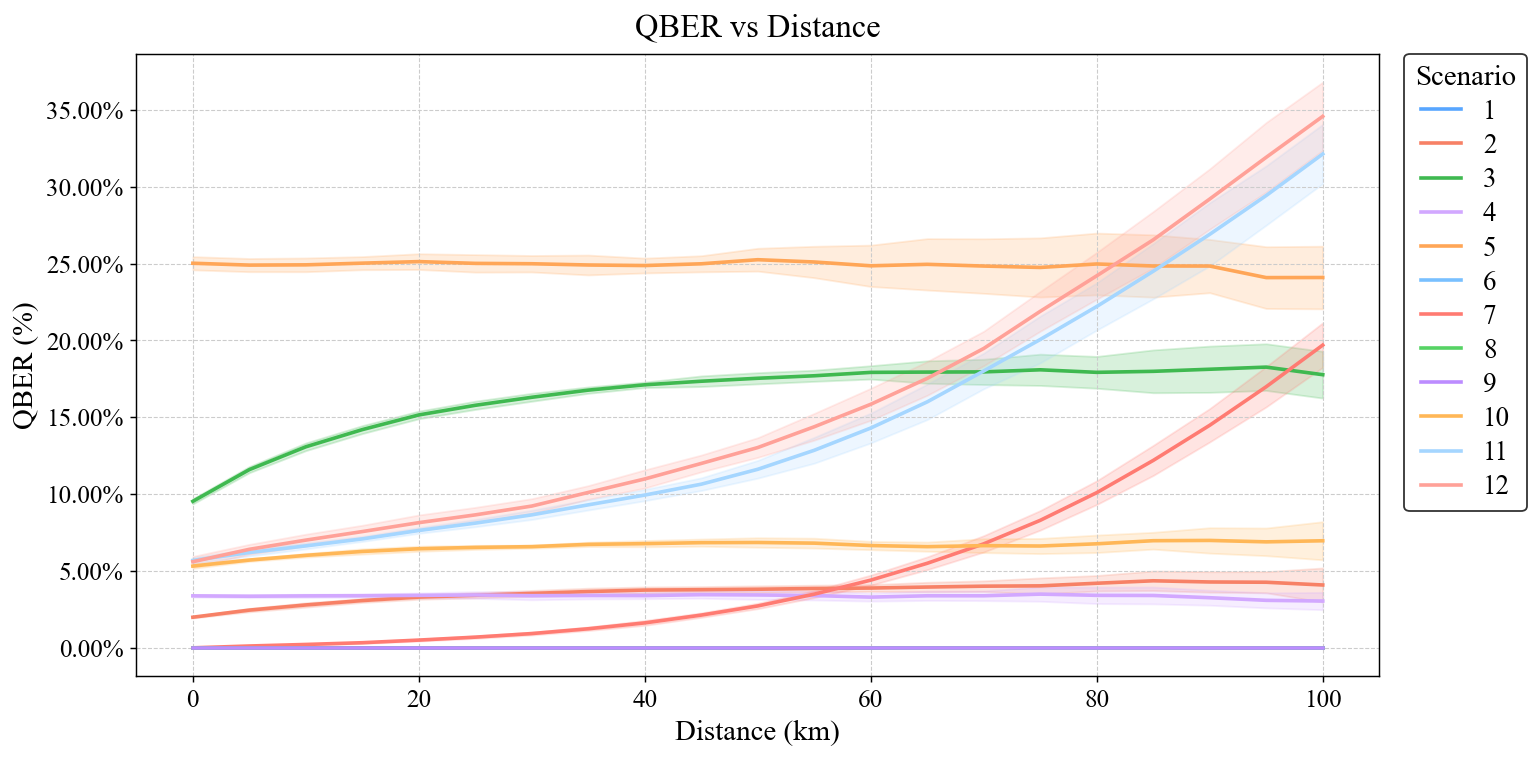

In [7]:
plot_all_scenarios_metric(
    "qber", "QBER (%)",
    "QBER vs Distance",
    pct_fmt=True,
    fname="comparativa_qber.png"
)


## 6. Comparativa multi-escenario — % Absorción

  Guardado: output_plots\comparativa_absorption.png


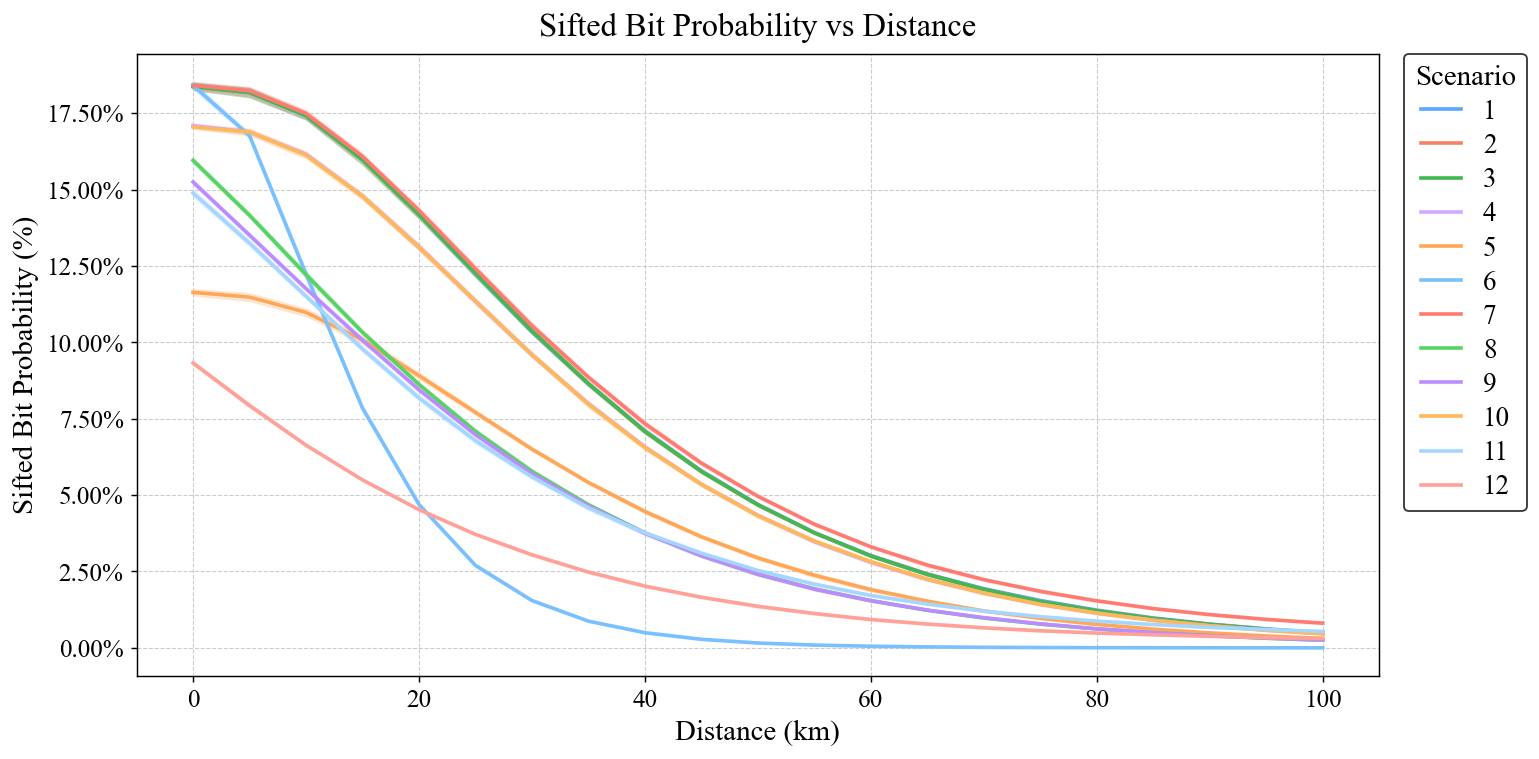

In [8]:
plot_all_scenarios_metric(
    "absorption", "Sifted Bit Probability (%)",
    "Sifted Bit Probability vs Distance",
    pct_fmt=True,
    fname="comparativa_absorption.png"
)


## 7. Comparativa multi-escenario — SKR

  Guardado: output_plots\comparativa_skr.png


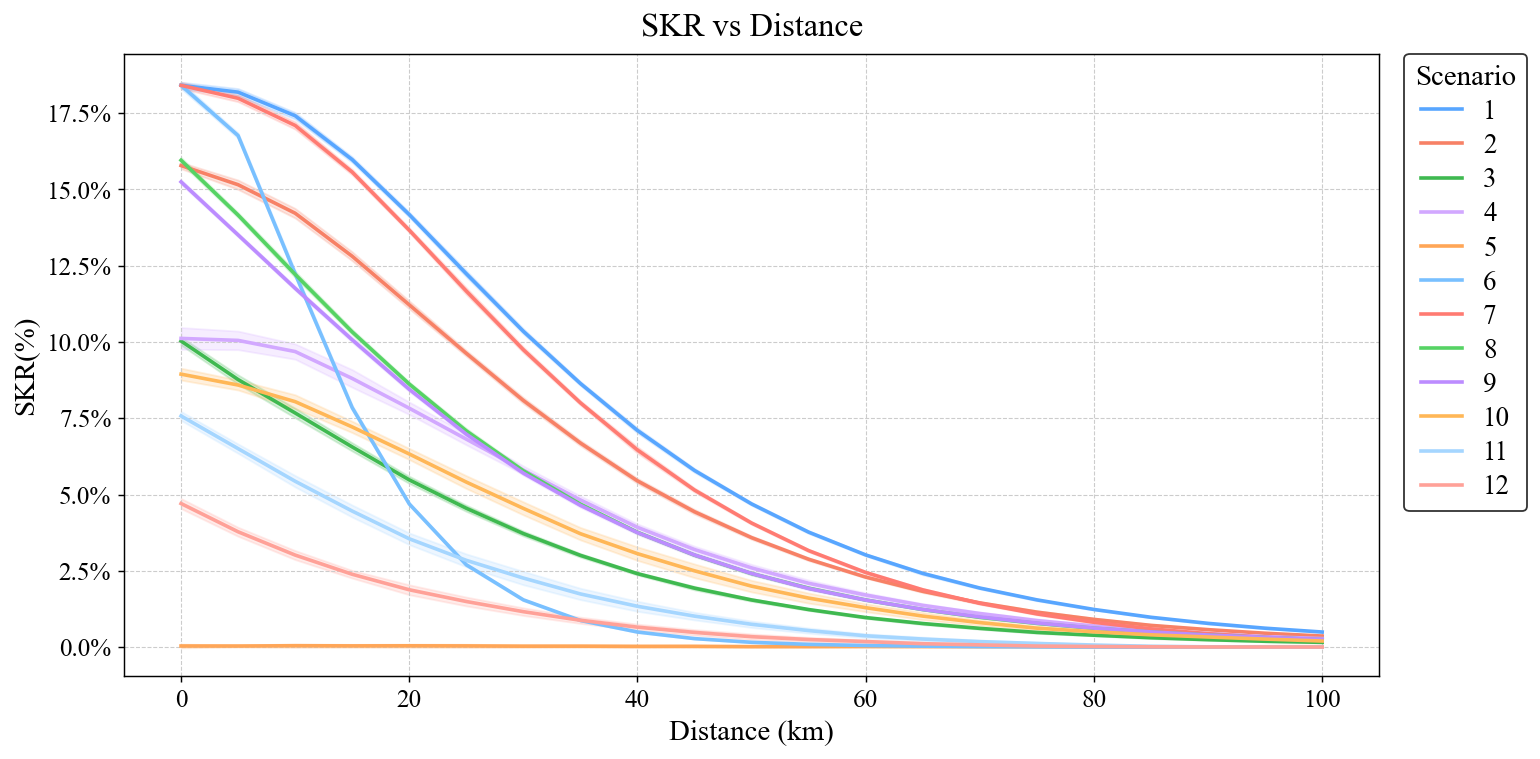

In [9]:
plot_all_scenarios_metric(
    "skr", "SKR(%)",
    "SKR vs Distance",
    log_y=False,
    fname="comparativa_skr.png"
)


## 8. Desviación estadística — detalle por escenario

In [10]:
def plot_std_detail(metric: str, ylabel_std: str, title: str, fname=None):
    """
    Muestra la desviación estándar entre semillas por escenario y distancia.
    Útil para evaluar la robustez estadística de la simulación.
    """
    keys = sorted(scenarios_data.keys())
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor("#ffffff")

    for i, key in enumerate(keys):
        df    = scenarios_data[key]
        dist  = df["distancia"].values
        std   = df[f"{metric}_std"].values * 100  # Convertir a porcentaje
        color = PALETTE[i % len(PALETTE)]
        label = str(i+1)  # Números del 1 al 12 en la leyenda
        ax.plot(dist, std, color=color, linewidth=1.6, label=label, marker="o",
                markersize=3)

    ax.set_xlabel("Distance (km)")
    ax.set_ylabel(ylabel_std)
    ax.set_title(title, pad=10)
    ax.legend(
        title="Scenario",
        fontsize=15,            # Tamaño grande para los números
        title_fontsize=16,      # Tamaño grande para el título
        framealpha=0.8,
        loc="upper left",       # Fuera de la gráfica
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
        ncol=1,
        handlelength=1.5,
        labelspacing=0.3,
        borderpad=0.4
    )
    plt.tight_layout()

    if fname:
        path = os.path.join(PLOTS_DIR, fname)
        plt.savefig(path, bbox_inches="tight", dpi=150)
        print(f"  Guardado: {path}")
    plt.show()


  Guardado: output_plots\std_qber_detalle.png


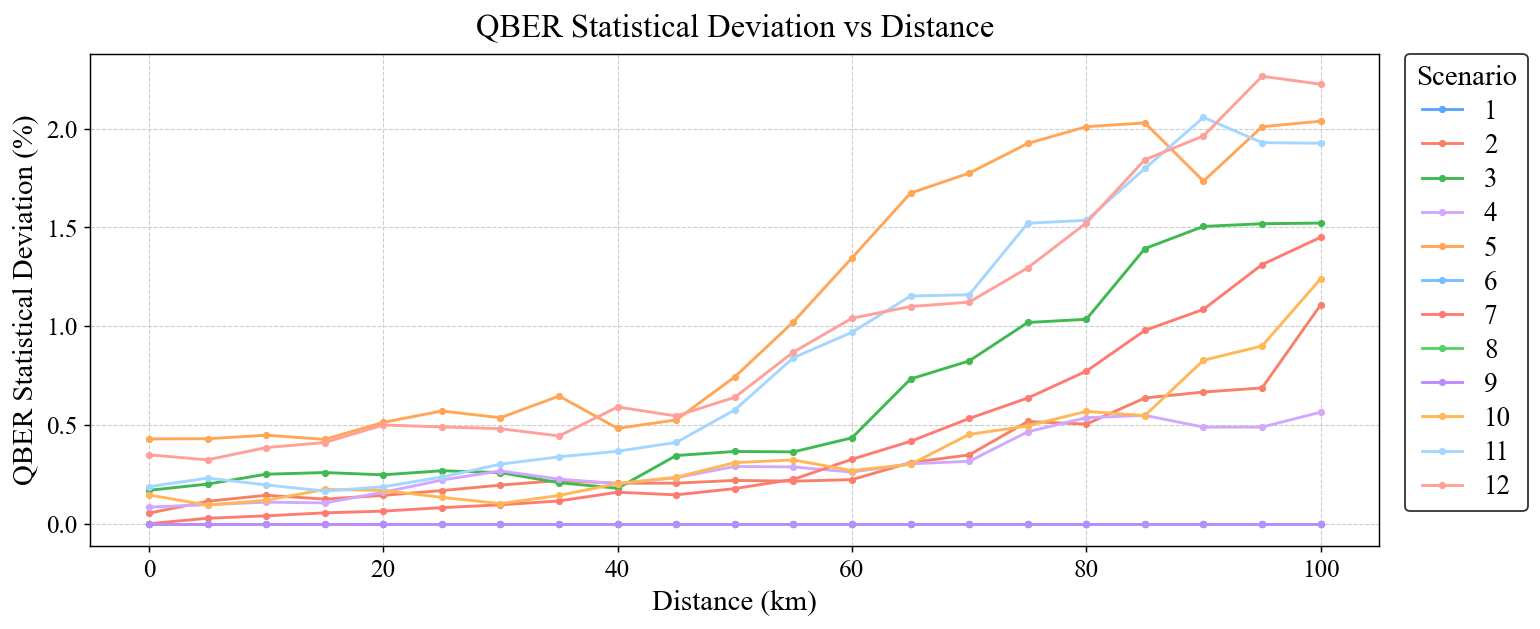

In [11]:
plot_std_detail(
    "qber", "QBER Statistical Deviation (%)",
    "QBER Statistical Deviation vs Distance",
    fname="std_qber_detalle.png"
)
